### Introdução

Este notebook tem como intuito implementar o método de regressão logística para prever a aprovação e reprovação de estudantes da EAFIT. 

#### 1.1 Importação de bibliotecas

In [7]:
# Importação das bibliotecas principais
import pandas as pd  # Manipulação e análise de dados em formato tabular
import matplotlib.pyplot as plt  # Visualização de dados e criação de gráficos

# Scikit-learn - divisão de dados e validação
from sklearn.model_selection import train_test_split  # Divisão do dataset em treino e teste

# Scikit-learn - modelo de machine learning
from sklearn.linear_model import LogisticRegression  # Algoritmo de classificação para previsão binária

# Scikit-learn - métricas de avaliação
from sklearn.metrics import accuracy_score  # Calcula a taxa de acerto do modelo
from sklearn.metrics import classification_report  # Gera relatório detalhado com várias métricas

# Scikit-learn - pré-processamento de dados
from sklearn.impute import SimpleImputer  # Tratamento de valores faltantes (substitui por média, mediana, etc.)
from sklearn.preprocessing import StandardScaler  # Normalização dos dados (padronização das features)

# Scikit-learn - pipeline
from sklearn.pipeline import Pipeline  # Cadeia de processos (pré-processamento + modelo)

# Scikit-learn - matriz de confusão
from sklearn.metrics import confusion_matrix  # Calcula a matriz de confusão
from sklearn.metrics import ConfusionMatrixDisplay  # Visualização gráfica da matriz de confusão

#### 1.2 Pipeline do modelo

Este bloco de código treina e avalia um modelo de regressão logística para um problema de classificação. Ele automatiza o processo de leitura de um arquivo CSV, lida com valores ausentes, divide os dados, treina o modelo usando um pipeline e, por fim, imprime métricas de avaliação como acurácia e o relatório de classificação.

In [8]:
def train_and_evaluate(csv_path):
    try:
        # Tenta executar o código abaixo e captura erros se eles ocorrerem.
        df = pd.read_csv(csv_path)

        # Lida com valores ausentes preenchendo-os com a média de cada coluna.
        imputer = SimpleImputer(strategy='mean')
        df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
        
        # Separa a variável alvo (y) das variáveis independentes (X).
        # 'Aprovou_Aprovou' é a coluna que queremos prever.
        y = df_imputed['Reprovou']
        X = df_imputed.drop('Reprovou', axis=1)
        
        # Divide os dados em 80% para treinamento e 20% para teste.
        # O random_state garante que a divisão seja a mesma a cada execução.
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Cria um pipeline para encadear as etapas de pré-processamento e o modelo.
        # 1. Normaliza os dados (StandardScaler) para que o modelo funcione melhor.
        # 2. Treina o modelo de Regressão Logística.
        model_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('logistic_regression', LogisticRegression())
        ])
        
        # Treina o pipeline com os dados de treinamento.
        model_pipeline.fit(X_train, y_train)
        
        # Faz previsões no conjunto de teste para avaliar o modelo.
        y_pred = model_pipeline.predict(X_test)
        
        # Imprime o nome do arquivo sendo processado.
        print(f"Resultados para {csv_path}:")
        
        # Calcula e imprime a acurácia (porcentagem de previsões corretas).
        print("Acurácia:", accuracy_score(y_test, y_pred))
        
        # Imprime um relatório detalhado com métricas como precisão, recall e F1-score.
        print("Relatório de Classificação:\n", classification_report(y_test, y_pred))
    
    # Bloco de tratamento de erros.
    except FileNotFoundError:
        print(f"ERRO: O arquivo '{csv_path}' não foi encontrado.")
    except KeyError:
        print(f"ERRO: A coluna 'Aprovou_Aprovou' não foi encontrada no arquivo '{csv_path}'.")
    except Exception as e:
        # Captura e imprime qualquer outro erro inesperado.
        print(f"ERRO inesperado ao processar '{csv_path}': {e}")
    
    # Imprime uma linha separadora para facilitar a leitura.
    print("-" * 50)

#### 1.3 Execução para primeira fatia de dados

In [9]:
# Testando para a primeira fatia de dados (referente a janela anterior a primeira verificação proposta pelo parceiro)
train_and_evaluate('dados/dados_modelo1.csv')

Resultados para dados/dados_modelo1.csv:
Acurácia: 0.96
Relatório de Classificação:
               precision    recall  f1-score   support

         0.0       0.97      0.99      0.98       264
         1.0       0.50      0.27      0.35        11

    accuracy                           0.96       275
   macro avg       0.74      0.63      0.67       275
weighted avg       0.95      0.96      0.95       275

--------------------------------------------------


#### 1.4 Execução para segunda fatia de dados

In [10]:
# Testando para a segunda fatia de dados (período anterior a segunda verificação proposta pelo parceiro)
train_and_evaluate('dados/dados_modelo2.csv')

Resultados para dados/dados_modelo2.csv:
Acurácia: 0.96
Relatório de Classificação:
               precision    recall  f1-score   support

         0.0       0.98      0.98      0.98       264
         1.0       0.50      0.45      0.48        11

    accuracy                           0.96       275
   macro avg       0.74      0.72      0.73       275
weighted avg       0.96      0.96      0.96       275

--------------------------------------------------


#### 1.5 Execução para a terceira fatia de dados

In [11]:
# Testando para a terceira fatia de dados (período anterior a última verificação proposta pelo parceior)
train_and_evaluate('dados/dados_modelo3.csv')

Resultados para dados/dados_modelo3.csv:
Acurácia: 0.96
Relatório de Classificação:
               precision    recall  f1-score   support

         0.0       0.98      0.98      0.98       264
         1.0       0.50      0.55      0.52        11

    accuracy                           0.96       275
   macro avg       0.74      0.76      0.75       275
weighted avg       0.96      0.96      0.96       275

--------------------------------------------------


#### 1.6 Matriz de confusão

 Executa a matriz de confusão, uma matriz de confusão é uma tabela usada para descrever o desempenho de um modelo de classificação em um conjunto de dados de teste para o qual os valores verdadeiros são conhecidos.

 Ao todo são 3 execuções, cada uma para cada fatia de dados.

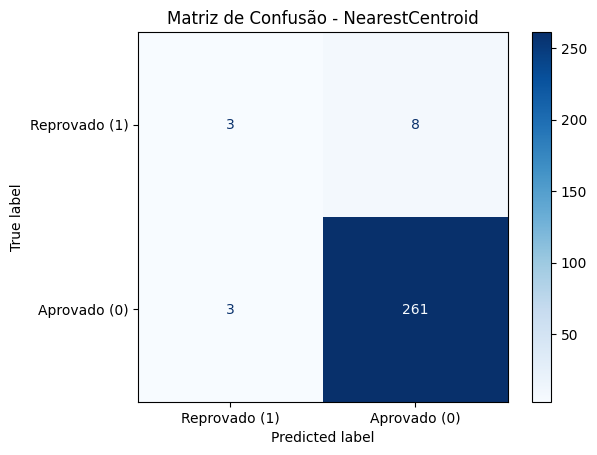

In [ ]:
# Usando os dados do último modelo treinado (modelo1)
df = pd.read_csv('dados/dados_modelo1.csv')
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

y = df_imputed['Reprovou']
X = df_imputed.drop('Reprovou', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression())
])

model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Reprovado (1)", "Aprovado (0)"],  
    cmap="Blues",
    values_format="d",
    labels = [1,0]
)

plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

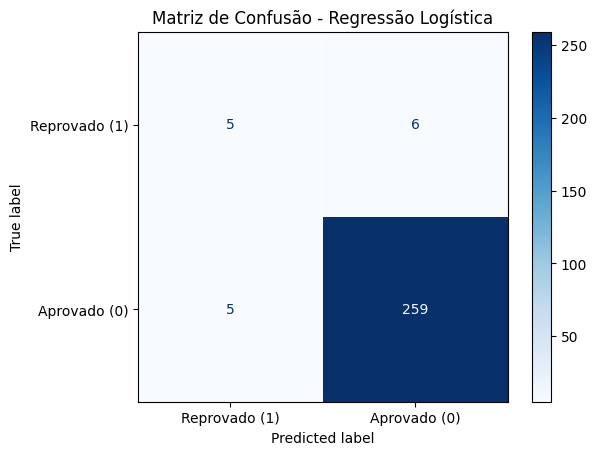

In [16]:
# Usando os dados do último modelo treinado (modelo2)
df = pd.read_csv('dados/dados_modelo2.csv')
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

y = df_imputed['Reprovou']
X = df_imputed.drop('Reprovou', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression())
])

model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Reprovado (1)", "Aprovado (0)"],  
    cmap="Blues",
    values_format="d",
    labels = [1,0]
)

plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

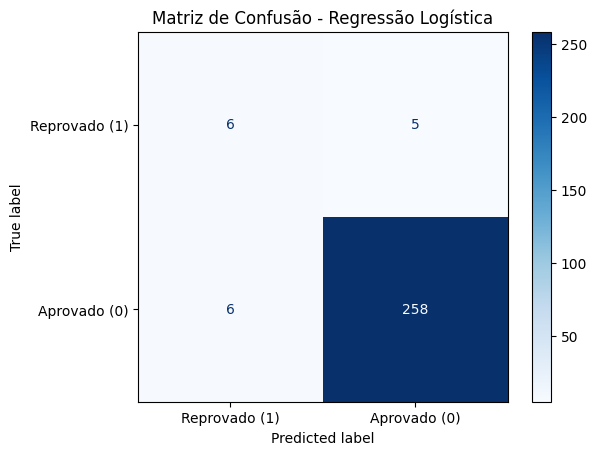

In [17]:
# Usando os dados do último modelo treinado (modelo3)
df = pd.read_csv('dados/dados_modelo3.csv')
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

y = df_imputed['Reprovou']
X = df_imputed.drop('Reprovou', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression())
])

model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Reprovado (1)", "Aprovado (0)"],  
    cmap="Blues",
    values_format="d",
    labels = [1,0]
)

plt.title("Matriz de Confusão - Regressão Logística")
plt.show()